# 데이터 확인하기 #
## 0. 라이브러리 임포트 & 경로 설정

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 0. 라이브러리 임포트 & 경로 설정

import os
import json
import pandas as pd
from PIL import Image
import unicodedata  # 0번 섹션에 추가 필요
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torchvision
import torchvision.transforms as T
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import matplotlib
import matplotlib.pyplot as plt
from collections import Counter
import subprocess
import matplotlib as mpl
import numpy as np
import matplotlib.patches as patches
!pip3 install ultralytics -q
from ultralytics import YOLO
from ultralytics.utils import LOGGER
import logging
import shutil
import unicodedata
!pip3 install iterative-stratification -q
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 70.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# ── 디바이스 ──────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ── 한글 폰트 ─────────────────────────────────────────────
subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
subprocess.run(['fc-cache', '-fv'], capture_output=True)
mpl.font_manager.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
mpl.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# ── 경로 설정 ─────────────────────────────────────────────
BASE_DIR            = unicodedata.normalize('NFC', "/content/drive/MyDrive/data/초급_프로젝트/dataset/")

TRAIN_JSON_PATH     = os.path.join(BASE_DIR, "merged_annotations_train_final.json")
TEST_JSON_PATH      = os.path.join(BASE_DIR, "merged_annotations_test_final.json")
TRAIN_IMG_DIR       = os.path.join(BASE_DIR, "train_images")
TEST_IMG_DIR        = os.path.join(BASE_DIR, "test_images")
PROCESSED_IMG_DIR   = os.path.join(BASE_DIR, "processed_images_v3")
PROCESSED_JSON_PATH = os.path.join(BASE_DIR, "processed_train_v3.json")
YOLO_DATASET_DIR    = os.path.join(BASE_DIR, "yolo_dataset_v3")
YOLO_RUNS_DIR       = os.path.join(BASE_DIR, "yolo_runs_v3")
SUBMISSION_PATH     = os.path.join(BASE_DIR, "submission_v3.csv")

for d in [PROCESSED_IMG_DIR, YOLO_DATASET_DIR, YOLO_RUNS_DIR]:
    os.makedirs(d, exist_ok=True)

# ── 경로 검증 ─────────────────────────────────────────────
for name, path in [
    ("TRAIN JSON   ", TRAIN_JSON_PATH),
    ("TEST  JSON   ", TEST_JSON_PATH),
    ("TRAIN IMG DIR", TRAIN_IMG_DIR),
    ("TEST  IMG DIR", TEST_IMG_DIR),
]:
    print(f"  {name} : {'OK' if os.path.exists(path) else '없음'} ({path})")

Device: cuda
  TRAIN JSON    : OK (/content/drive/MyDrive/data/초급_프로젝트/dataset/merged_annotations_train_final.json)
  TEST  JSON    : OK (/content/drive/MyDrive/data/초급_프로젝트/dataset/merged_annotations_test_final.json)
  TRAIN IMG DIR : OK (/content/drive/MyDrive/data/초급_프로젝트/dataset/train_images)
  TEST  IMG DIR : OK (/content/drive/MyDrive/data/초급_프로젝트/dataset/test_images)


## 1. 파일 존재 여부 및 기본 구조 확인

In [ ]:
# 이미지 파일 개수 확인
IMG_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp')

def count_images(directory):
    """디렉토리 내 이미지 파일 수를 반환"""
    if not os.path.exists(directory):
        return 0
    return sum(
        1 for entry in os.scandir(directory)
        if entry.is_file() and entry.name.lower().endswith(IMG_EXTENSIONS)
    )

EXPECTED = {"Train": 1489, "Test": 843}

n_train = count_images(TRAIN_IMG_DIR)
n_test  = count_images(TEST_IMG_DIR)

print(f"Train 이미지 수 : {n_train:,}  (기대값: {EXPECTED['Train']:,})")
print(f"Test  이미지 수 : {n_test:,}  (기대값: {EXPECTED['Test']:,})")
print(f"합계            : {n_train + n_test:,}")

if n_train != EXPECTED["Train"]:
    print(f"[경고] Train 이미지 수 불일치: {n_train} != {EXPECTED['Train']}")
if n_test != EXPECTED["Test"]:
    print(f"[경고] Test  이미지 수 불일치: {n_test} != {EXPECTED['Test']}")

Train 이미지 수 : 1,489  (기대값: 1,489)
Test  이미지 수 : 843  (기대값: 843)
합계            : 2,332


In [ ]:
# 샘플 데이터 구조 확인
with open(TRAIN_JSON_PATH, 'r', encoding='utf-8') as f:
    train_json = json.load(f)

with open(TEST_JSON_PATH, 'r', encoding='utf-8') as f:
    test_json = json.load(f)

# ── 최상위 키 및 건수 ──────────────────────────────────────
for label, data in [("Train", train_json), ("Test", test_json)]:
    print(f"[{label}] 최상위 키: {list(data.keys())}")
    print(f"  images      : {len(data.get('images', [])):,}건")
    print(f"  annotations : {len(data.get('annotations', [])):,}건")
    print(f"  categories  : {len(data.get('categories', [])):,}건")
    print()

# ── 샘플 1건씩 출력 ───────────────────────────────────────
print("=== images[0] ===")
print(train_json['images'][0])

print("\n=== annotations[0] ===")
print(train_json['annotations'][0])

print("\n=== categories (앞 5개) ===")
for cat in train_json['categories'][:5]:
    print(cat)

# ── category_id 범위 및 연속성 확인 ──────────────────────
cat_ids = sorted(c['id'] for c in train_json['categories'])
expected_ids = list(range(min(cat_ids), max(cat_ids) + 1))
is_continuous = cat_ids == expected_ids

print(f"\ncategory_id 범위 : {min(cat_ids)} ~ {max(cat_ids)}")
print(f"연속성           : {'연속' if is_continuous else '[경고] 불연속 (재매핑 필요)'}")

[Train] 최상위 키: ['images', 'annotations', 'categories']
  images      : 1,489건
  annotations : 4,526건
  categories  : 73건

[Test] 최상위 키: ['images', 'annotations', 'categories']
  images      : 843건
  annotations : 1,129건
  categories  : 73건

=== images[0] ===
{'file_name': 'K-001900-016551-024850-027926_0_2_0_2_90_000_200.png', 'width': 976, 'height': 1280, 'imgfile': 'K-001900-016551-024850-027926_0_2_0_2_90_000_200.png', 'drug_N': 'K-001900', 'drug_S': '정상알약', 'back_color': '연회색 배경', 'drug_dir': '앞면', 'light_color': '주백색', 'camera_la': 90, 'camera_lo': 0, 'size': 200, 'dl_idx': '1899', 'dl_mapping_code': 'K-001900', 'dl_name': '보령부스파정 5mg', 'dl_name_en': 'Buspar Tab. 5mg Boryung', 'img_key': 'http://connectdi.com/design/img/drug/1Mxwka5v0lL.jpg', 'dl_material': '부스피론염산염', 'dl_material_en': 'Buspirone Hydrochloride', 'dl_custom_shape': '정제, 저작정', 'dl_company': '보령제약(주)', 'dl_company_en': 'Boryung', 'di_company_mf': '', 'di_company_mf_en': '', 'item_seq': 198700706, 'di_item_permit_date

## 3. 클래스 분포 분석

클래스 수 : 73  |  전체 어노테이션 : 4,526
평균 : 62.0  |  중앙값 : 35.0  |  최대/최소 비율 : 73.4x

최다 : 기넥신에프정(은행엽엑스)(수출용) (514개)
최소 : 브린텔릭스정 20mg (7개)

상위 5개:
              name  count
기넥신에프정(은행엽엑스)(수출용)    514
       일양하이트린정 2mg    240
        보령부스파정 5mg    180
       뮤테란캡슐 100mg    172
       가바토파정 100mg    143

하위 5개:
        name  count
 졸로푸트정 100mg     11
  쿠에타핀정 25mg     10
자이프렉사정 2.5mg      9
  렉사프로정 15mg      9
 브린텔릭스정 20mg      7


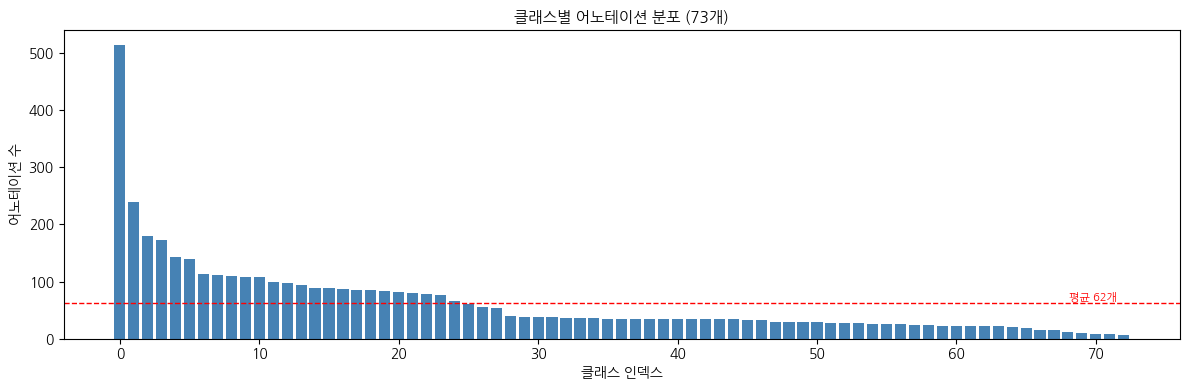

In [ ]:
# 클래스 분포 확인
id2name = {cat['id']: cat['name'] for cat in train_json['categories']}
cat_counter = Counter(annot['category_id'] for annot in train_json['annotations'])

df_class = pd.DataFrame([
    {'category_id': cid, 'name': id2name.get(cid, '?'), 'count': cnt}
    for cid, cnt in cat_counter.most_common()
])

print(f"클래스 수 : {len(df_class)}  |  전체 어노테이션 : {df_class['count'].sum():,}")
print(f"평균 : {df_class['count'].mean():.1f}  |  중앙값 : {df_class['count'].median():.1f}  |  최대/최소 비율 : {df_class['count'].max() / df_class['count'].min():.1f}x")
print(f"\n최다 : {df_class.iloc[0]['name']} ({df_class.iloc[0]['count']}개)")
print(f"최소 : {df_class.iloc[-1]['name']} ({df_class.iloc[-1]['count']}개)")

print("\n상위 5개:")
print(df_class.head(5)[['name', 'count']].to_string(index=False))
print("\n하위 5개:")
print(df_class.tail(5)[['name', 'count']].to_string(index=False))

# 전체 분포 시각화
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(df_class)), df_class['count'], color='steelblue', edgecolor='none')
mean_val = df_class['count'].mean()
ax.axhline(mean_val, color='red', linestyle='--', linewidth=1)
ax.text(len(df_class) * 0.98, mean_val + 5, f"평균 {mean_val:.0f}개", color='red', fontsize=8, ha='right')
ax.set_title('클래스별 어노테이션 분포 (73개)', fontsize=11)
ax.set_xlabel('클래스 인덱스')
ax.set_ylabel('어노테이션 수')
plt.tight_layout()
plt.show()

## 4. EDA (데이터 정보 확인)

[Train] 해상도 분포:
  976 x 1280: 1489장
[Test] 해상도 분포:
  976 x 1280: 843장

annotation 없는 이미지: 0장
평균 알약 수: 3.04개 | 최대: 4개

  1개:   64장 (4.3%)
  2개:  302장 (20.3%)
  3개:  634장 (42.6%)
  4개:  489장 (32.8%)


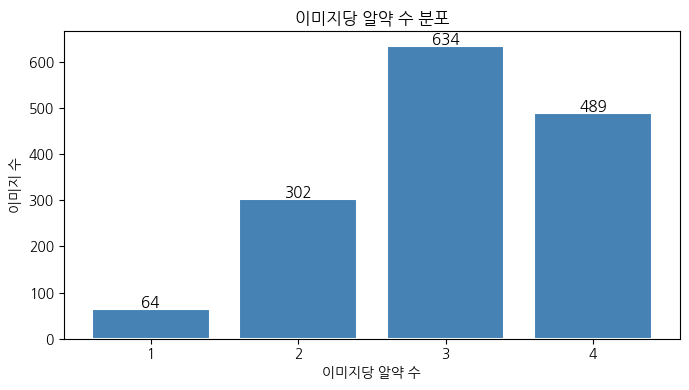

In [ ]:
# 해상도 및 알약 수 분포 확인
for label, data in [("Train", train_json), ("Test", test_json)]:
    resolutions = Counter((img['width'], img['height']) for img in data['images'])
    print(f"[{label}] 해상도 분포:")
    for (w, h), cnt in resolutions.most_common():
        print(f"  {w} x {h}: {cnt}장")

ann_per_image = Counter(ann['image_id'] for ann in train_json['annotations'])
no_ann = {img['id'] for img in train_json['images']} - set(ann_per_image.keys())
print(f"\nannotation 없는 이미지: {len(no_ann)}장")

counts = list(ann_per_image.values())
pill_dist = Counter(counts)
print(f"평균 알약 수: {np.mean(counts):.2f}개 | 최대: {np.max(counts)}개\n")
for k in sorted(pill_dist.keys()):
    print(f"  {k}개: {pill_dist[k]:4d}장 ({pill_dist[k]/len(train_json['images'])*100:.1f}%)")

fig, ax = plt.subplots(figsize=(7, 4))
keys, vals = zip(*sorted(pill_dist.items()))
bars = ax.bar(keys, vals, color='steelblue', edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 5, str(v), ha='center', fontsize=11, fontweight='bold')
ax.set_xlabel('이미지당 알약 수')
ax.set_ylabel('이미지 수')
ax.set_title('이미지당 알약 수 분포')
ax.set_xticks(keys)
plt.tight_layout()
plt.show()

In [ ]:
# 비정상 BBox 탐지
img_id2info = {img['id']: img for img in train_json['images']}
invalid_bboxes = []

for ann in train_json['annotations']:
    img = img_id2info[ann['image_id']]
    x, y, w, h = ann['bbox']
    iw, ih = img['width'], img['height']

    reasons = []
    if x < 0 or y < 0:           reasons.append(f"음수 좌표 (x={x}, y={y})")
    if w <= 0 or h <= 0:          reasons.append(f"비정상 크기 (w={w}, h={h})")
    if x + w > iw:                reasons.append(f"x 범위 초과 (x+w={x+w} > {iw})")
    if y + h > ih:                reasons.append(f"y 범위 초과 (y+h={y+h} > {ih})")
    if reasons:
        invalid_bboxes.append({
            'ann_id'  : ann['id'],
            'image_id': ann['image_id'],
            'bbox'    : ann['bbox'],
            'reason'  : ' / '.join(reasons)
        })

print(f"비정상 BBox 수: {len(invalid_bboxes)}개")
for item in invalid_bboxes:
    print(f"  ann_id={item['ann_id']} / image_id={item['image_id']} / bbox={item['bbox']} / 사유={item['reason']}")

비정상 BBox 수: 2개
  ann_id=903 / image_id=239 / bbox=[6567, 625, 311, 315] / 사유=x 범위 초과 (x+w=6878 > 976)
  ann_id=1157 / image_id=310 / bbox=[653, 8889, 217, 217] / 사유=y 범위 초과 (y+h=9106 > 1280)


In [ ]:
# ── file_name ↔ 실제 파일 매칭 검증 ──────────────────────
actual_files = {entry.name for entry in os.scandir(TRAIN_IMG_DIR) if entry.is_file()}

missing = []
for img in train_json['images']:
    if img['file_name'] not in actual_files:
        missing.append(img['file_name'])

print(f"JSON 등록 이미지 수  : {len(train_json['images']):,}장")
print(f"실제 파일 수         : {len(actual_files):,}장")
print(f"매칭 실패 (누락 파일): {len(missing)}장")

if missing:
    print("\n누락 파일 목록:")
    for f in missing:
        print(f"  {f}")
else:
    print("모든 파일 정상 매칭")

JSON 등록 이미지 수  : 1,489장
실제 파일 수         : 1,489장
매칭 실패 (누락 파일): 0장
모든 파일 정상 매칭


## 5. 데이터 전처리 ##

### 5-1. 비정상 BBox 제거 ###

In [ ]:
# 비정상 BBox 제거
invalid_ann_ids = {item['ann_id'] for item in invalid_bboxes}
clean_annotations = [ann for ann in train_json['annotations'] if ann['id'] not in invalid_ann_ids]

print(f"제거 전 : {len(train_json['annotations']):,}개")
print(f"제거 수 : {len(invalid_ann_ids)}개")
print(f"제거 후 : {len(clean_annotations):,}개")

제거 전 : 4,526개
제거 수 : 2개
제거 후 : 4,524개


### 5-2. category_id 재맵핑

In [ ]:
# category_id 재매핑 (원본 id → 0~72 연속 정수)
sorted_cats = sorted(train_json['categories'], key=lambda c: c['id'])

old_id2new  = {cat['id']: new_id for new_id, cat in enumerate(sorted_cats)}
new_id2old  = {new_id: cat['id'] for new_id, cat in enumerate(sorted_cats)}
new_id2name = {new_id: cat['name'].strip() for new_id, cat in enumerate(sorted_cats)}

remapped_annotations = []
for ann in clean_annotations:
    new_ann = ann.copy()
    new_ann['category_id'] = old_id2new[ann['category_id']]
    remapped_annotations.append(new_ann)

remapped_categories = [
    {'id': new_id, 'name': new_id2name[new_id], 'supercategory': 'pill'}
    for new_id in range(len(sorted_cats))
]

new_cat_ids = sorted(set(ann['category_id'] for ann in remapped_annotations))
print(f"category_id 범위 : {min(new_cat_ids)} ~ {max(new_cat_ids)}")
print(f"고유 클래스 수   : {len(new_cat_ids)}개")
print(f"연속성           : {'연속' if new_cat_ids == list(range(len(new_cat_ids))) else '[경고] 불연속'}")
print(f"annotation 수    : {len(remapped_annotations):,}개")

category_id 범위 : 0 ~ 72
고유 클래스 수   : 73개
연속성           : 연속
annotation 수    : 4,524개


### 5-3. letterbox 리사이즈 ###
976x1280 -> 1280x1280

- 이미지를 비율을 유지한 상태로 크기를 조절함
- 빈 공간은 padding으로 채움

In [ ]:
# Letterbox 리사이즈 (976×1280 → 1280×1280)
TARGET_SIZE = 1280
PAD_COLOR   = (114, 114, 114)

def letterbox_image(img, target=TARGET_SIZE):
    iw, ih = img.size
    scale  = min(target / iw, target / ih)
    new_w  = int(iw * scale)
    new_h  = int(ih * scale)
    pad_w  = (target - new_w) // 2
    pad_h  = (target - new_h) // 2

    resized = img.resize((new_w, new_h), Image.BILINEAR)
    canvas  = Image.new('RGB', (target, target), PAD_COLOR)
    canvas.paste(resized, (pad_w, pad_h))
    return canvas, scale, pad_w, pad_h

def transform_bbox(bbox, scale, pad_w, pad_h):
    x, y, w, h = bbox
    return [
        x * scale + pad_w,
        y * scale + pad_h,
        w * scale,
        h * scale
    ]

# 이미지 저장 및 BBox 변환
img_id2transform = {}

for img_info in train_json['images']:
    src_path = os.path.join(TRAIN_IMG_DIR, img_info['file_name'])
    dst_path = os.path.join(PROCESSED_IMG_DIR, img_info['file_name'])

    img = Image.open(src_path).convert('RGB')
    processed, scale, pad_w, pad_h = letterbox_image(img)
    processed.save(dst_path)
    img_id2transform[img_info['id']] = (scale, pad_w, pad_h)

# BBox 좌표 변환
processed_annotations = []
for ann in remapped_annotations:
    scale, pad_w, pad_h = img_id2transform[ann['image_id']]
    new_ann = ann.copy()
    new_ann['bbox'] = transform_bbox(ann['bbox'], scale, pad_w, pad_h)
    processed_annotations.append(new_ann)

print(f"처리 완료 : {len(img_id2transform):,}장")
print(f"scale={scale:.4f} | pad_w={pad_w}px | pad_h={pad_h}px")
print(f"annotation 수 : {len(processed_annotations):,}개")

OSError: image file is truncated

### 5-4. train/val 분리 ###

***Multi-label Stratified Split**

동작 방식

- 이미지 내 모든 클래스를 동시에 고려해 분할
- 각 클래스의 train/val 비율이 동시에 80:20에 가깝도록 최적화
- iterative-stratification 라이브러리 사용

In [ ]:
# Train/Val Multi-label Stratified Split

# 이미지별 annotation 그룹화
img2anns = {}
for ann in processed_annotations:
    img2anns.setdefault(ann['image_id'], []).append(ann)

img_ids  = np.array(sorted(img2anns.keys()))
n_classes = len(remapped_categories)

# 이미지별 멀티핫 벡터 생성 (73차원)
y = np.zeros((len(img_ids), n_classes), dtype=int)
for i, img_id in enumerate(img_ids):
    for ann in img2anns[img_id]:
        y[i, ann['category_id']] = 1

# 클래스당 이미지 1장인 경우 강제 train 배정
class_counts = y.sum(axis=0)
single_classes = np.where(class_counts == 1)[0]
force_train_mask = np.any(y[:, single_classes] == 1, axis=1) if len(single_classes) > 0 else np.zeros(len(img_ids), dtype=bool)

remaining_idx = np.where(~force_train_mask)[0]
force_idx     = np.where(force_train_mask)[0]

# Multi-label stratified split
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(msss.split(remaining_idx, y[remaining_idx]))

train_ids = img_ids[remaining_idx[train_idx]].tolist() + img_ids[force_idx].tolist()
val_ids   = img_ids[remaining_idx[val_idx]].tolist()

# 검증
train_y = y[[i for i, img_id in enumerate(img_ids) if img_id in set(train_ids)]]
val_y   = y[[i for i, img_id in enumerate(img_ids) if img_id in set(val_ids)]]

print(f"Train : {len(train_ids)}장 | Val : {len(val_ids)}장")
print(f"Train 클래스 수 : {train_y.sum(axis=0).astype(bool).sum()}개")
print(f"Val   클래스 수 : {val_y.sum(axis=0).astype(bool).sum()}개")
print(f"강제 train 배정 : {len(force_idx)}장")

### 5-5. 전처리된 JSON 저장 ###

In [ ]:
# 전처리 JSON 저장
processed_images = []
for img in train_json['images']:
    new_img = img.copy()
    new_img['width']  = TARGET_SIZE
    new_img['height'] = TARGET_SIZE
    processed_images.append(new_img)

processed_json = {
    'images'     : processed_images,
    'annotations': processed_annotations,
    'categories' : remapped_categories,
    'train_ids'  : list(train_ids),
    'val_ids'    : list(val_ids),
    'mappings'   : {
        'old_id2new' : {str(k): v for k, v in old_id2new.items()},
        'new_id2old' : {str(k): v for k, v in new_id2old.items()},
        'new_id2name': {str(k): v for k, v in new_id2name.items()},
    }
}

with open(PROCESSED_JSON_PATH, 'w', encoding='utf-8') as f:
    json.dump(processed_json, f, ensure_ascii=False, indent=2)

with open(PROCESSED_JSON_PATH, 'r', encoding='utf-8') as f:
    verify = json.load(f)

print(f"images      : {len(verify['images']):,}장")
print(f"annotations : {len(verify['annotations']):,}개")
print(f"categories  : {len(verify['categories'])}개")
print(f"train_ids   : {len(verify['train_ids']):,}장")
print(f"val_ids     : {len(verify['val_ids']):,}장")
print(f"image size  : {verify['images'][0]['width']} x {verify['images'][0]['height']}")
cat_ids = [ann['category_id'] for ann in verify['annotations']]
print(f"category_id : {min(cat_ids)} ~ {max(cat_ids)}")

### 5-6. 전처리 결과 검증 ###

In [ ]:
# 전처리 최종 검증
train_id_set = set(train_ids)
val_id_set   = set(val_ids)
train_annotations = [ann for ann in processed_annotations if ann['image_id'] in train_id_set]
val_annotations   = [ann for ann in processed_annotations if ann['image_id'] in val_id_set]

# 1. 이미지 파일 수 및 크기 검증
processed_files = [f for f in os.scandir(PROCESSED_IMG_DIR) if f.name.lower().endswith(IMG_EXTENSIONS)]
print(f"저장된 이미지 수 : {len(processed_files):,}장 (기대값: {len(processed_images):,}장)")

size_errors = [f.name for f in processed_files if Image.open(f.path).size != (TARGET_SIZE, TARGET_SIZE)]
print(f"크기 오류        : {len(size_errors)}장" + (f"\n  {size_errors}" if size_errors else " (정상)"))

# 2. BBox 좌표 범위 검증
bbox_errors = []
for ann in processed_annotations:
    x, y, w, h = ann['bbox']
    reasons = []
    if x < 0 or y < 0:          reasons.append(f"음수 좌표 (x={x:.1f}, y={y:.1f})")
    if w <= 0 or h <= 0:         reasons.append(f"비정상 크기 (w={w:.1f}, h={h:.1f})")
    if x + w > TARGET_SIZE:      reasons.append(f"x 범위 초과 ({x+w:.1f} > {TARGET_SIZE})")
    if y + h > TARGET_SIZE:      reasons.append(f"y 범위 초과 ({y+h:.1f} > {TARGET_SIZE})")
    if reasons:
        bbox_errors.append({'ann_id': ann['id'], 'reason': ' / '.join(reasons)})

print(f"비정상 BBox      : {len(bbox_errors)}개" + (f"\n  {bbox_errors}" if bbox_errors else " (정상)"))

# 3. Train/Val 클래스 분포 비율 검증
total_cat_counts = Counter(ann['category_id'] for ann in processed_annotations)
train_cat_counts = Counter(ann['category_id'] for ann in train_annotations)
val_cat_counts   = Counter(ann['category_id'] for ann in val_annotations)

print(f"\n{'new_id':<8} {'클래스명':<30} {'전체':>6} {'Train':>6} {'Val':>5} {'Val비율':>8}")
print("-" * 70)
ratio_errors = []
for cat_id in range(len(remapped_categories)):
    total     = total_cat_counts.get(cat_id, 0)
    train     = train_cat_counts.get(cat_id, 0)
    val       = val_cat_counts.get(cat_id, 0)
    val_ratio = val / total if total > 0 else 0
    flag      = " [경고]" if abs(val_ratio - 0.2) > 0.15 and total >= 5 else ""
    print(f"  {cat_id:<6} {new_id2name[cat_id]:<30} {total:>6} {train:>6} {val:>5} {val_ratio:>7.1%}{flag}")
    if flag:
        ratio_errors.append(cat_id)

print(f"\n비율 이상 클래스 : {len(ratio_errors)}개")
print(f"Train 클래스 수  : {len(train_cat_counts)}개")
print(f"Val   클래스 수  : {len(val_cat_counts)}개")

## 6. DataLoader 구성 ##

***모델 : YOLOv8m***

현재 가장 널리 쓰이는 1-stage detector입니다. 속도와 정확도 균형이 뛰어나고, Ultralytics 라이브러리로 학습/추론 코드가 매우 간결합니다.

- 장점: 빠른 학습 속도, 코드 간결, 데이터 증강 내장, mAP 성능 우수
- 단점: YOLO 포맷으로 데이터 변환 필요
- 권장 batch_size: 8~16
- 권장 모델 크기: yolov8m (medium) - 속도/정확도 균형

-----
#### 모델 ####
- 모델: YOLOv8m
- 사전학습 가중치: yolov8m.pt (COCO)

#### 데이터 ####
- 이미지 크기: 1280x1280
- 클래스 수: 73
- Train: 1,182장 / Val: 307장
- 포맷: YOLO (x_center, y_center, w, h 정규화)

#### 학습 하이퍼파라미터 ####
- epochs: 100
- batch_size: 10
- optimizer: AdamW
- learning_rate: 0.001
- image_size: 1280

#### 데이터 증강 (YOLOv8 내장) ####
- Mosaic : 활성화
- MixUp : 활성화
- HSV 색상 변환 : 비활성화
- degrees : 비활성화

#### 학습 설정 ####
- Early stopping: patience=20
- 체크포인트 저장: Google Drive

#### 미결정 사항 (추후 진행) ####
- 클래스 불균형 해소 전략 (Focal Loss / 클래스 가중치)
- confidence threshold
- IoU threshold (NMS)
- Kaggle 제출 포맷 변환 (YOLO 출력 → COCO 포맷)


### 6-1. 이미지 포멧 변환 ###

COCO(기존 이미지 형식) [x, y, w, h] → YOLO [x_center, y_center, w, h]

심볼릭 링크(Symbolic Link)를 사용하여 실제 파일을 복사하지 않고, 원본 파일의 경로를 가리키는 포인터를 만들어 사용한다.

심볼릭 링크는 실제 파일 없이 원본을 참조하므로 용량 추가 없이 YOLO가 요구하는 디렉토리 구조를 만들 수 있습니다.

In [ ]:
# YOLO 포맷 변환
YOLO_LABEL_TRAIN = os.path.join(YOLO_DATASET_DIR, "labels", "train")
YOLO_LABEL_VAL   = os.path.join(YOLO_DATASET_DIR, "labels", "val")
YOLO_IMG_TRAIN   = os.path.join(YOLO_DATASET_DIR, "images", "train")
YOLO_IMG_VAL     = os.path.join(YOLO_DATASET_DIR, "images", "val")
YOLO_YAML_PATH   = os.path.join(YOLO_DATASET_DIR, "data.yaml")

for d in [YOLO_LABEL_TRAIN, YOLO_LABEL_VAL, YOLO_IMG_TRAIN, YOLO_IMG_VAL]:
    os.makedirs(d, exist_ok=True)

def coco_to_yolo(bbox, img_w, img_h):
    x, y, w, h = bbox
    x_c = min(max((x + w / 2) / img_w, 0.0), 1.0)
    y_c = min(max((y + h / 2) / img_h, 0.0), 1.0)
    w_n = min(max(w / img_w, 0.0), 1.0)
    h_n = min(max(h / img_h, 0.0), 1.0)
    return x_c, y_c, w_n, h_n

img_id2anns  = {}
for ann in processed_annotations:
    img_id2anns.setdefault(ann['image_id'], []).append(ann)

def write_yolo(img_ids, label_dir, img_dir):
    count = 0
    for img_info in processed_images:
        if img_info['id'] not in set(img_ids):
            continue
        label_path = os.path.join(label_dir, os.path.splitext(img_info['file_name'])[0] + '.txt')
        with open(label_path, 'w') as f:
            for ann in img_id2anns.get(img_info['id'], []):
                x_c, y_c, w_n, h_n = coco_to_yolo(ann['bbox'], img_info['width'], img_info['height'])
                f.write(f"{ann['category_id']} {x_c:.6f} {y_c:.6f} {w_n:.6f} {h_n:.6f}\n")
        shutil.copy2(
            os.path.join(PROCESSED_IMG_DIR, img_info['file_name']),
            os.path.join(img_dir, img_info['file_name'])
        )
        count += 1
    return count

n_train = write_yolo(train_ids, YOLO_LABEL_TRAIN, YOLO_IMG_TRAIN)
n_val   = write_yolo(val_ids,   YOLO_LABEL_VAL,   YOLO_IMG_VAL)

yaml_content = f"""train: {YOLO_IMG_TRAIN}
val: {YOLO_IMG_VAL}

nc: {len(remapped_categories)}
names: {[new_id2name[i] for i in range(len(remapped_categories))]}
"""
with open(YOLO_YAML_PATH, 'w', encoding='utf-8') as f:
    f.write(yaml_content)

# 검증
n_ti = len(os.listdir(YOLO_IMG_TRAIN))
n_vi = len(os.listdir(YOLO_IMG_VAL))
n_tl = len(os.listdir(YOLO_LABEL_TRAIN))
n_vl = len(os.listdir(YOLO_LABEL_VAL))

print(f"Train 이미지: {n_ti:,} / 라벨: {n_tl:,}")
print(f"Val   이미지: {n_vi:,} / 라벨: {n_vl:,}")
if n_ti != n_tl: print("[경고] Train 이미지/라벨 수 불일치")
if n_vi != n_vl: print("[경고] Val 이미지/라벨 수 불일치")

sample = os.listdir(YOLO_LABEL_TRAIN)[0]
print(f"\n샘플 라벨 ({sample}):")
with open(os.path.join(YOLO_LABEL_TRAIN, sample)) as f:
    print(f.read())

### 6-2. 모델 학습 코드

In [ ]:
# YOLOv8m 학습
EXPERIMENT_NAME = "yolov8m_oral_drug_v3"

def on_train_epoch_end(trainer):
    epoch    = trainer.epoch + 1
    epochs   = trainer.epochs
    box_loss = trainer.loss_items[0].item() if trainer.loss_items is not None else 0
    cls_loss = trainer.loss_items[1].item() if trainer.loss_items is not None else 0
    dfl_loss = trainer.loss_items[2].item() if trainer.loss_items is not None else 0
    print(f"[Epoch {epoch:3d}/{epochs}]  box_loss: {box_loss:.4f}  cls_loss: {cls_loss:.4f}  dfl_loss: {dfl_loss:.4f}")

def on_val_end(validator):
    metrics = validator.metrics
    map50   = metrics.box.map50 if hasattr(metrics, 'box') else 0
    map5095 = metrics.box.map   if hasattr(metrics, 'box') else 0
    print(f"           └─ Val  mAP50: {map50:.4f}  mAP50-95: {map5095:.4f}")

def on_train_end(trainer):
    print(f"\n{'='*55}")
    print(f"학습 완료  |  저장 경로: {trainer.save_dir}")
    print(f"{'='*55}")

model = YOLO("yolov8m.pt")
model.add_callback("on_train_epoch_end", on_train_epoch_end)
model.add_callback("on_val_end",         on_val_end)
model.add_callback("on_train_end",       on_train_end)

results = model.train(
    data         = YOLO_YAML_PATH,
    imgsz        = 768,
    epochs       = 50,
    batch        = 16,
    optimizer    = "AdamW",
    lr0          = 0.001,
    lrf          = 0.01,
    weight_decay = 0.0005,
    warmup_epochs= 3,
    mosaic       = 1.0,
    mixup        = 0.1,
    fliplr       = 0.0,
    flipud       = 0.0,
    patience     = 20,
    save         = True,
    project      = YOLO_RUNS_DIR,
    name         = EXPERIMENT_NAME,
    exist_ok     = True,
    device       = 0,
    workers      = 8,
    verbose      = False,
)